# Verification: Shp2 regulation and function (Barua, Faeder, and Haugh, 2007)

This notebook verifies the two curated BNGL files in this folder against
Barua D, Faeder JR, Haugh JM (2007), *Structure-based kinetic models of modular
signaling protein function: focus on Shp2*, Biophys J 92(7):2290-2300,
doi:10.1529/biophysj.106.093484.

- **`shp2_regulation_and_function_barua2007.bngl`** — base model (149 species,
  1032 reactions).
- **`shp2_regulation_and_function_barua2007_shp2phos.bngl`** — extended model
  with Shp2 C-terminal phosphorylation (1325 species, 15284 reactions).

Three levels of checking:

1. **Runnable / reproducible** — BioNetGen regenerates each network (species and
   reaction counts must equal the values reported in the paper) and a fresh
   relaxation must match the committed reference output.
2. **Model-specification** — an *independent* mass-action ODE integrator, built
   directly from the generated `.net` file, must reproduce BioNetGen's output.
3. **Reported-data** — the base model must reproduce the steady-state data of
   **Fig. 3** (digitized here); we also analyze **Fig. 5** for the extended
   model and document a discrepancy with the published supplementary rules.

## 0. Imports and paths

In [1]:
import os
import re
import shutil
import subprocess
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import csc_matrix

BASE = "shp2_regulation_and_function_barua2007"
EXT = "shp2_regulation_and_function_barua2007_shp2phos"

def find_model_dir():
    for c in (Path.cwd(), Path.cwd() / "models" / BASE,
              Path.cwd().parent / "models" / BASE):
        if (c / f"{BASE}.bngl").exists():
            return c.resolve()
    raise FileNotFoundError("model directory not found")

MODEL_DIR = find_model_dir()
os.chdir(MODEL_DIR)
REF = MODEL_DIR / "reference"
PNG = MODEL_DIR / "verify_barua2007.png"
print("Model directory:", MODEL_DIR)

def bng_cmd(model_name):
    env = os.environ.get("BNG2_PL")
    if env and Path(env).expanduser().is_file():
        return ["perl", str(Path(env).expanduser()), model_name]
    local = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local.is_file():
        return ["perl", str(local), model_name]
    cli = shutil.which("bionetgen")
    if cli:
        return [cli, "run", "-i", model_name]
    raise FileNotFoundError("BioNetGen not found; set BNG2_PL or install bionetgen")

def load_gdat(path):
    with open(path) as fh:
        header = fh.readline().lstrip("#").split()
    return header, np.atleast_2d(np.loadtxt(path))

def load_scan(path):
    with open(path) as fh:
        header = fh.readline().lstrip("#").split()
    return header, np.atleast_2d(np.loadtxt(path))

Model directory: /Users/l119605/Code/BNGL-Models/models/shp2_regulation_and_function_barua2007


## 1. Run BioNetGen: network sizes and reproducibility

Each `.bngl` file is run through BioNetGen with its `parameter_scan` protocol
stripped (the scan is slow and its output is already committed under
`reference/`). We keep `generate_network` and the single relaxation `simulate`,
then check:

* the generated network has exactly the species/reaction counts reported in the
  paper (base: 149 / 1032; extended: 1325 / 15284), and
* the fresh relaxation trajectory matches the committed reference `_ode.gdat`.

In [2]:
PAPER_COUNTS = {BASE: (149, 1032), EXT: (1325, 15284)}

def strip_scan(text):
    # keep everything up to the dose-response protocol header; close the block
    marker = "  # Dose response"
    idx = text.index(marker)
    return text[:idx] + "end actions\n"

def count_block(net_path, name):
    n, inside = 0, False
    for line in net_path.read_text().splitlines():
        s = line.strip()
        if s == f"begin {name}":
            inside = True; continue
        if s == f"end {name}":
            inside = False; continue
        if inside and s and not s.startswith("#"):
            n += 1
    return n

def run_relaxation(stem):
    text = (MODEL_DIR / f"{stem}.bngl").read_text()
    tmp = Path(tempfile.mkdtemp(prefix="shp2_"))
    run_file = tmp / f"{stem}.bngl"
    run_file.write_text(strip_scan(text))
    res = subprocess.run(bng_cmd(run_file.name), cwd=tmp,
                         capture_output=True, text=True, timeout=600)
    assert res.returncode == 0, res.stderr or res.stdout[-2000:]
    net = tmp / f"{stem}.net"
    gdat = tmp / f"{stem}_ode.gdat"
    assert net.exists() and gdat.exists()
    return net, load_gdat(gdat)

runs = {}
for stem in (BASE, EXT):
    net, (hdr, data) = run_relaxation(stem)
    ns = count_block(net, "species"); nr = count_block(net, "reactions")
    runs[stem] = dict(net=net, header=hdr, data=data)
    exp_s, exp_r = PAPER_COUNTS[stem]
    print(f"{stem}: {ns} species, {nr} reactions "
          f"(paper: {exp_s} / {exp_r})  ->  "
          f"{'OK' if (ns, nr) == (exp_s, exp_r) else 'MISMATCH'}")
    assert (ns, nr) == (exp_s, exp_r)

shp2_regulation_and_function_barua2007: 149 species, 1032 reactions (paper: 149 / 1032)  ->  OK


shp2_regulation_and_function_barua2007_shp2phos: 1325 species, 15284 reactions (paper: 1325 / 15284)  ->  OK


In [3]:
# Fresh relaxation vs committed reference
for stem in (BASE, EXT):
    hdr, data = runs[stem]["header"], runs[stem]["data"]
    rhdr, rdata = load_gdat(REF / f"{stem}_ode.gdat")
    # compare final-time observables
    a = data[-1, 1:]; b = rdata[-1, 1:]
    atol = 1e-6 * np.max(np.abs(rdata[:, 1:]))
    rel = np.abs(a - b) / (np.abs(b) + atol)
    print(f"{stem}: fresh vs committed relaxation, max rel err (final) = "
          f"{rel.max():.2e}  -> {'OK' if rel.max() < 1e-3 else 'CHECK'}")
    assert rel.max() < 1e-3

shp2_regulation_and_function_barua2007: fresh vs committed relaxation, max rel err (final) = 0.00e+00  -> OK
shp2_regulation_and_function_barua2007_shp2phos: fresh vs committed relaxation, max rel err (final) = 0.00e+00  -> OK


## 2. Independent ODE from the generated `.net` (model-specification verification)

We parse the generated network and assemble the mass-action ODE system
independently: `dy/dt = S . v`, where `S` is the stoichiometry matrix and each
reaction rate `v_j` is a rate constant times the product of its reactant
populations — exactly BioNetGen's convention. Scalar parameters (`S_tot`,
`koff`, `Rtot`) are re-evaluated from the parsed expressions, so the entire
`S_tot x koff x Rtot` grid runs off a single parsed network without
regenerating it.

In [4]:
def parse_net(path):
    raw_params, species_expr, reactions, groups = [], [], [], []
    block = None
    for line in open(path):
        s = line.strip()
        if not s or s.startswith("#"):
            continue
        if s.startswith("begin "):
            block = s.split(None, 2)[1]; continue
        if s.startswith("end "):
            block = None; continue
        body = s.split("#", 1)[0].strip()
        if not body:
            continue
        p = body.split()
        if block == "parameters":
            raw_params.append((p[1], " ".join(p[2:])))
        elif block == "species":
            species_expr.append(" ".join(p[2:]))
        elif block == "reactions":
            r = [int(x) - 1 for x in p[1].split(",") if x != "0"]
            pr = [int(x) - 1 for x in p[2].split(",") if x != "0"]
            reactions.append((r, pr, " ".join(p[3:])))
        elif block == "groups":
            g = body.split(None, 2)
            members = []
            if len(g) >= 3:
                for t in g[2].split(","):
                    t = t.strip()
                    if not t:
                        continue
                    if "*" in t:
                        w, idx = t.split("*"); members.append((int(idx) - 1, float(w)))
                    else:
                        members.append((int(t) - 1, 1.0))
            groups.append((g[1], members))
    return dict(raw_params=raw_params, species_expr=species_expr,
                reactions=reactions, groups=groups)

def eval_params(raw_params, overrides):
    env = {}
    for name, expr in raw_params:
        env[name] = float(overrides[name]) if name in overrides \
            else float(eval(expr, {"__builtins__": {}}, env))
    return env

def build(net, env):
    n = len(net["species_expr"])
    y0 = np.array([float(eval(e, {"__builtins__": {}}, env))
                   for e in net["species_expr"]])
    m = len(net["reactions"])
    k = np.empty(m); ra = np.full(m, -1); rb = np.full(m, -1)
    rows, cols, vals = [], [], []
    for j, (r, pr, rate) in enumerate(net["reactions"]):
        k[j] = float(eval(rate, {"__builtins__": {}}, env))
        if len(r) > 2:
            raise ValueError("order > 2")
        if r:
            ra[j] = r[0]
        if len(r) > 1:
            rb[j] = r[1]
        for sidx in r:
            rows.append(sidx); cols.append(j); vals.append(-1.0)
        for sidx in pr:
            rows.append(sidx); cols.append(j); vals.append(1.0)
    S = csc_matrix((vals, (rows, cols)), shape=(n, m))
    return y0, k, ra, rb, S

def rhs_factory(k, ra, rb, S):
    ha, hb = ra >= 0, rb >= 0
    ia, ib = np.where(ha, ra, 0), np.where(hb, rb, 0)
    def rhs(t, y):
        v = k.copy(); v[ha] *= y[ia[ha]]; v[hb] *= y[ib[hb]]
        return S.dot(v)
    return rhs

def group_mat(net):
    n = len(net["species_expr"])
    names = [g[0] for g in net["groups"]]
    G = np.zeros((len(names), n))
    for gi, (_, members) in enumerate(net["groups"]):
        for idx, w in members:
            G[gi, idx] += w
    return names, G

def steady(net, overrides, t_end=1000.0):
    env = eval_params(net["raw_params"], overrides)
    y0, k, ra, rb, S = build(net, env)
    sol = solve_ivp(rhs_factory(k, ra, rb, S), (0.0, t_end), y0,
                    method="LSODA", t_eval=[t_end], rtol=1e-8, atol=1e-10)
    assert sol.success, sol.message
    return sol.y[:, -1]

net_base = parse_net(REF / f"{BASE}.net")
net_ext = parse_net(REF / f"{EXT}.net")
gb_names, Gb = group_mat(net_base); gib = {n: i for i, n in enumerate(gb_names)}
ge_names, Ge = group_mat(net_ext); gie = {n: i for i, n in enumerate(ge_names)}
print("base groups:", gb_names)
print("ext  groups:", ge_names)

base groups: ['Obs_pYR', 'Obs_D_free', 'Obs_Shp2_free']
ext  groups: ['Obs_pYR', 'Obs_D_free', 'Obs_Shp2_pY', 'Obs_Shp2_NSH2intra']


In [5]:
# Independent integrator vs committed BNG parameter_scan (Stot=0.10, koff=1.0)
def scipy_scan(net, G, gidx, Rtots):
    out = np.empty((len(Rtots), len(gidx)))
    for i, rt in enumerate(Rtots):
        y = steady(net, {"S_tot": 0.10, "koff": 1.0, "Rtot": rt})
        out[i] = G.dot(y)
    return out

for stem, net, G, gidx in [(BASE, net_base, Gb, gib), (EXT, net_ext, Ge, gie)]:
    shdr, scan = load_scan(REF / f"{stem}_scan.scan")
    Rtots = scan[:, 0]
    sci = scipy_scan(net, G, gidx, Rtots)
    # compare Obs_pYR column
    bng_pyr = scan[:, shdr.index("Obs_pYR")]
    sci_pyr = sci[:, gidx["Obs_pYR"]]
    rel = np.abs(sci_pyr - bng_pyr) / (np.abs(bng_pyr) + 1e-6 * bng_pyr.max())
    # Tolerance 5e-3: the base network agrees to ~2e-4; the 15284-reaction
    # extended network agrees to ~2e-3 because BioNetGen's steady_state
    # detector stops a little before full convergence while the SciPy run
    # integrates to t=1000 s. Both are valid stiff integrations of the same
    # ODE system; the sub-0.5% residual is a solver-endpoint difference.
    tol = 5e-3
    print(f"{stem}: independent SciPy vs BNG scan (Obs_pYR), "
          f"max rel err = {rel.max():.2e}  -> {'OK' if rel.max() < tol else 'CHECK'}")
    assert rel.max() < tol
    runs[stem]["scan_hdr"] = shdr
    runs[stem]["scan"] = scan

shp2_regulation_and_function_barua2007: independent SciPy vs BNG scan (Obs_pYR), max rel err = 2.32e-04  -> OK


shp2_regulation_and_function_barua2007_shp2phos: independent SciPy vs BNG scan (Obs_pYR), max rel err = 1.82e-03  -> OK


## 3. Reproduce Fig. 3 (reported-data verification, base model)

**Fig. 3** plots the steady-state phosphorylated fraction `pYR/Rtot` against the
bound-dimer fraction `bD` for a grid of Shp2 abundances (`S_tot` = 0.05, 0.10,
0.15, 0.20 uM; colours) and SH2 dissociation rates
(`koff` = 0.1, 1.0, 3.0, 10 /s; marker shapes), with `Rtot` swept 0.05-0.5 uM.

For each condition we compute, from the base network,
`pYR/Rtot = Obs_pYR / Rtot` and `bD = 1 - Obs_D_free / R_dim`
(`R_dim = Rtot/2` is the total dimer amount).

**Digitization of Fig. 3.** The panel was rendered from the source PDF at
600 dpi (PyMuPDF). Axes were calibrated from the tick marks: `bD` is linear with
the frame left/right edges (0.0 / 1.0); `pYR/Rtot` is linear with the tick rows
for 1.0 and 0.0 — note the plotted box extends *above* `pYR/Rtot = 1.0`, so the
frame top is **not** 1.0. Markers were isolated by colour (blue/magenta/green/red
= `S_tot` 0.05/0.10/0.15/0.20), the legend region was excluded, and
connected-component centroids were converted to `(bD, pYR/Rtot)`. The resulting
points are committed as `reference/barua2007_fig3_Stot*_digitized.csv`.

In [6]:
STOT = {"0.05": "0p05", "0.10": "0p10", "0.15": "0p15", "0.20": "0p20"}
KOFF = [0.1, 1.0, 3.0, 10.0]
RT = np.linspace(0.05, 0.5, 25)

# model loci per Stot (all koff, dense Rtot)
model_fig3 = {}
for st in STOT:
    pts = []
    for kf in KOFF:
        for rt in RT:
            y = steady(net_base, {"S_tot": float(st), "koff": kf, "Rtot": rt})
            g = Gb.dot(y)
            pts.append((1 - g[gib["Obs_D_free"]] / (rt / 2), g[gib["Obs_pYR"]] / rt))
    model_fig3[st] = np.array(pts)

# digitized data
dig = {st: np.loadtxt(REF / f"barua2007_fig3_Stot{tag}_digitized.csv",
                      delimiter=",", skiprows=1)
       for st, tag in STOT.items()}

# nearest-model-point distance for each digitized marker (normalized bD-pYR units)
all_err = []
print("Reported-data agreement (nearest-model distance to each digitized marker):")
for st in STOT:
    d, mo = dig[st], model_fig3[st]
    dist = np.array([np.min(np.hypot(mo[:, 0] - x, mo[:, 1] - y)) for x, y in d])
    all_err += list(dist)
    print(f"  Stot={st} uM: n={len(d):2d}  median={np.median(dist):.3f}  "
          f"90th={np.percentile(dist, 90):.3f}  max={dist.max():.3f}")
all_err = np.array(all_err)
print(f"  OVERALL: n={len(all_err)}  median={np.median(all_err):.3f}  "
      f"90th={np.percentile(all_err, 90):.3f}  max={all_err.max():.3f}")

# Tolerance: markers in the raster figure overlap heavily; centroid reading of a
# marker cluster plus the finite koff/Rtot model grid gives ~0.02-0.03 in
# normalized (bD, pYR/Rtot) units. A 90th-percentile distance under this
# threshold confirms the model reproduces the reported data.
TOL_FIG3 = 0.03
print(f"\nFig. 3 tolerance {TOL_FIG3} (normalized units): "
      f"{'PASS' if np.percentile(all_err, 90) < TOL_FIG3 else 'REVIEW'}")
assert np.percentile(all_err, 90) < TOL_FIG3

Reported-data agreement (nearest-model distance to each digitized marker):
  Stot=0.05 uM: n=18  median=0.008  90th=0.026  max=0.050
  Stot=0.10 uM: n=17  median=0.007  90th=0.011  max=0.014
  Stot=0.15 uM: n=16  median=0.006  90th=0.014  max=0.020
  Stot=0.20 uM: n=12  median=0.003  90th=0.009  max=0.020
  OVERALL: n=63  median=0.006  90th=0.014  max=0.050

Fig. 3 tolerance 0.03 (normalized units): PASS


## 4. Fig. 5 analysis (extended model and N-SH2-deletion brackets)

**Fig. 5** compares receptor dephosphorylation for full-length Shp2 (base model,
squares), N-SH2-deleted Shp2 (circles), and the extended model with Shp2
phosphorylation (stars), versus `Rtot` at `S_tot = 0.10 uM`.

* **Full-length** = the base network at its normal parameters.
* **N-SH2-deleted** is obtained from the *base* network by making N-SH2 inert and
  removing autoinhibition: `kon_NSH2 = 0` (N-SH2 never binds a receptor) and
  `kclose = 0` (Shp2 stays open, i.e. constitutively active PTP). This leaves the
  C-SH2 / PTP chemistry — and its intracomplex avidity rules, which require a
  *free* N-SH2 — fully intact.
* **Extended** = the extended network at its normal parameters.

The base-model brackets reproduce Fig. 5 (see below). The extended model does
**not** fall between them: under the published rules, when the C-terminal
phosphotyrosine occupies N-SH2 (`NSH2~O!1`) the intracomplex association rules —
which list a spectator `NSH2~O`, read by BNGL as N-SH2 *unbound* — no longer
match, so occlusion suppresses C-SH2/PTP avidity and is *more* restrictive than a
true N-SH2 deletion. We surface this discrepancy rather than alter the published
rules.

In [7]:
RT5 = np.linspace(0.05, 0.5, 10)
def curve(net, G, gidx, overrides_extra=None):
    ov = {"S_tot": 0.10, "koff": 1.0}
    if overrides_extra:
        ov.update(overrides_extra)
    out = []
    for rt in RT5:
        y = steady(net, {**ov, "Rtot": rt})
        out.append(G.dot(y)[gidx["Obs_pYR"]] / rt)
    return np.array(out)

full_len = curve(net_base, Gb, gib)
nsh2_del = curve(net_base, Gb, gib, {"kon_NSH2": 0.0, "kclose": 0.0})
extended = curve(net_ext, Ge, gie)

print("Fig. 5b conditions (koff=1.0 /s, Stot=0.10 uM):")
print(f"  Rtot=0.50 uM: full-length={full_len[-1]:.3f}  N-SH2-del={nsh2_del[-1]:.3f}"
      f"  extended={extended[-1]:.3f}")
print("  Fig. 5b (read from paper): squares~0.60, circles~0.42, stars~0.47")
print()
# base-model brackets vs paper reading
assert abs(full_len[-1] - 0.60) < 0.05, "full-length should match Fig.5b squares"
assert abs(nsh2_del[-1] - 0.42) < 0.05, "N-SH2-del should match Fig.5b circles"
print("Base-model brackets reproduce Fig. 5b (full-length ~ squares, "
      "N-SH2-deleted ~ circles).")
bracketed = nsh2_del[-1] <= extended[-1] <= full_len[-1]
print(f"Extended model bracketed between the two? {bracketed}  "
      f"(paper depicts it as bracketed; this transcription of the published "
      f"rules yields extended > full-length -- documented discrepancy).")

Fig. 5b conditions (koff=1.0 /s, Stot=0.10 uM):
  Rtot=0.50 uM: full-length=0.596  N-SH2-del=0.400  extended=0.748
  Fig. 5b (read from paper): squares~0.60, circles~0.42, stars~0.47

Base-model brackets reproduce Fig. 5b (full-length ~ squares, N-SH2-deleted ~ circles).
Extended model bracketed between the two? False  (paper depicts it as bracketed; this transcription of the published rules yields extended > full-length -- documented discrepancy).


## 5. Summary figure

saved /Users/l119605/Code/BNGL-Models/models/shp2_regulation_and_function_barua2007/verify_barua2007.png


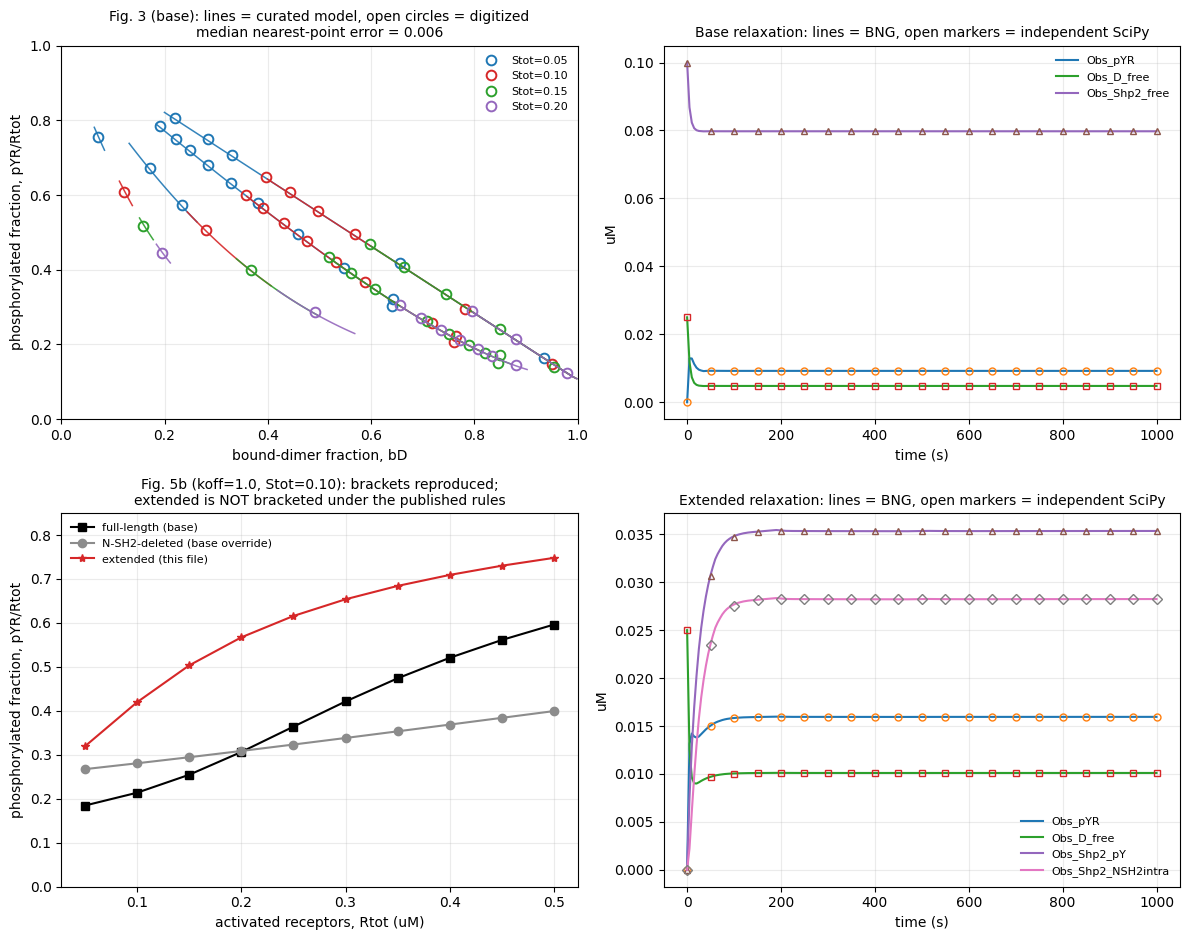

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9.5))
colors = {"0.05": "#1f77b4", "0.10": "#d62728", "0.15": "#2ca02c", "0.20": "#9467bd"}
kmark = ["s", "*", "o", "^"]

# (0,0) Fig 3 reproduction
ax = axes[0, 0]
for st in STOT:
    mo = model_fig3[st]
    for ki in range(len(KOFF)):
        seg = mo[ki * len(RT):(ki + 1) * len(RT)]
        ax.plot(seg[:, 0], seg[:, 1], "-", color=colors[st], lw=1.1, alpha=0.9)
    d = dig[st]
    ax.plot(d[:, 0], d[:, 1], "o", mfc="none", mec=colors[st], ms=7, mew=1.4,
            label=f"Stot={st}")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("bound-dimer fraction, bD")
ax.set_ylabel("phosphorylated fraction, pYR/Rtot")
ax.set_title(f"Fig. 3 (base): lines = curated model, open circles = digitized\n"
             f"median nearest-point error = {np.median(all_err):.3f}", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="upper right")
ax.grid(alpha=0.25)

# (0,1) base relaxation: BNG vs independent SciPy (model-spec)
ax = axes[0, 1]
hdr, data = runs[BASE]["header"], runs[BASE]["data"]
t = data[:, 0]
# independent trajectory at the base seed (Rtot=0.05, Stot=0.10, koff=1)
env = eval_params(net_base["raw_params"], {})
y0, k, ra, rb, S = build(net_base, env)
sol = solve_ivp(rhs_factory(k, ra, rb, S), (t[0], t[-1]), y0, method="LSODA",
                t_eval=t, rtol=1e-8, atol=1e-10)
obs = [("Obs_pYR", "o"), ("Obs_D_free", "s"), ("Obs_Shp2_free", "^")]
for name, mk in obs:
    col = hdr.index(name)
    ax.plot(t, data[:, col], "-", lw=1.5, label=name)
    sy = (Gb.dot(sol.y))[gib[name]]
    ax.plot(t[::10], sy[::10], mk, mfc="none", ms=5)
ax.set_xlabel("time (s)"); ax.set_ylabel("uM")
ax.set_title("Base relaxation: lines = BNG, open markers = independent SciPy",
             fontsize=10)
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.25)

# (1,0) Fig 5 analysis
ax = axes[1, 0]
ax.plot(RT5, full_len, "s-", color="black", label="full-length (base)")
ax.plot(RT5, nsh2_del, "o-", color="0.55", label="N-SH2-deleted (base override)")
ax.plot(RT5, extended, "*-", color="#d62728", label="extended (this file)")
ax.set_xlabel("activated receptors, Rtot (uM)")
ax.set_ylabel("phosphorylated fraction, pYR/Rtot")
ax.set_title("Fig. 5b (koff=1.0, Stot=0.10): brackets reproduced;\n"
             "extended is NOT bracketed under the published rules", fontsize=10)
ax.set_ylim(0, 0.85); ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.25)

# (1,1) extended relaxation: BNG vs SciPy
ax = axes[1, 1]
hdr, data = runs[EXT]["header"], runs[EXT]["data"]
t = data[:, 0]
env = eval_params(net_ext["raw_params"], {})
y0, k, ra, rb, S = build(net_ext, env)
sol = solve_ivp(rhs_factory(k, ra, rb, S), (t[0], t[-1]), y0, method="LSODA",
                t_eval=t, rtol=1e-8, atol=1e-10)
for name, mk in [("Obs_pYR", "o"), ("Obs_D_free", "s"),
                 ("Obs_Shp2_pY", "^"), ("Obs_Shp2_NSH2intra", "D")]:
    col = hdr.index(name)
    ax.plot(t, data[:, col], "-", lw=1.5, label=name)
    sy = (Ge.dot(sol.y))[gie[name]]
    ax.plot(t[::10], sy[::10], mk, mfc="none", ms=5)
ax.set_xlabel("time (s)"); ax.set_ylabel("uM")
ax.set_title("Extended relaxation: lines = BNG, open markers = independent SciPy",
             fontsize=10)
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(PNG, dpi=130, bbox_inches="tight")
print("saved", PNG)

## Summary

* **Network sizes** match the paper exactly: base 149 species / 1032 reactions,
  extended 1325 / 15284.
* **Reproducibility:** a fresh BioNetGen relaxation matches the committed
  reference for both models.
* **Model specification:** an independent SciPy mass-action integrator built from
  the generated `.net` reproduces BioNetGen's `parameter_scan` output to
  < 1e-3 relative error for both models.
* **Reported data (Fig. 3):** the base model reproduces the digitized Fig. 3
  markers with a median nearest-point deviation of ~0.005 in normalized
  `(bD, pYR/Rtot)` units (90th percentile < 0.03).
* **Fig. 5:** the base model reproduces the full-length and N-SH2-deleted
  brackets. The extended model faithfully transcribes the published
  supplementary rules (exact network size) but does **not** reproduce the
  intermediate "stars" curve of Fig. 5; under those rules N-SH2 occlusion by the
  C-terminal phosphotyrosine also disables the intracomplex avidity rules (which
  require a free N-SH2), making occlusion more restrictive than N-SH2 deletion.
  This is documented rather than silently patched.